<a href="https://colab.research.google.com/github/ElvinaShukurova/Telecom/blob/main/Lab6_Shukurova.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
if not os.path.exists('thinkdsp.py'):
    !wget https://github.com/AllenDowney/ThinkDSP/raw/master/code/thinkdsp.py

--2026-05-04 17:03:13--  https://github.com/AllenDowney/ThinkDSP/raw/master/code/thinkdsp.py
Resolving github.com (github.com)... 140.82.114.3
Connecting to github.com (github.com)|140.82.114.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/AllenDowney/ThinkDSP/master/code/thinkdsp.py [following]
--2026-05-04 17:03:14--  https://raw.githubusercontent.com/AllenDowney/ThinkDSP/master/code/thinkdsp.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.110.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 48554 (47K) [text/plain]
Saving to: ‘thinkdsp.py’

thinkdsp.py         100%[===================>]  47.42K  --.-KB/s    in 0.03s   

2026-05-04 17:03:14 (1.77 MB/s) - ‘thinkdsp.py’ saved [48554/48554]



In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from thinkdsp import decorate

# Упражнение 6.1


In [2]:
import numpy as np
from thinkdsp import *
import matplotlib.pyplot as plt
from scipy.fftpack import dct
TWO_PI = 2 * np.pi
def method_solve(signal, freqs, times):
    phase = np.outer(times, freqs)
    basis = np.cos(TWO_PI * phase)
    coeffs = np.linalg.solve(basis, signal)
    return coeffs
def method_dot(signal, freqs, times):
    phase = np.outer(times, freqs)
    basis = np.cos(TWO_PI * phase)
    coeffs = basis.dot(signal) / 2
    return coeffs
def generate_signal(N):
    times = np.arange(N) / N
    freqs = np.arange(N) / 2
    signal = np.cos(TWO_PI * 100 * times)
    return signal, freqs, times

In [3]:
sizes = [64, 128, 256, 512]
for n in sizes:
    signal, freqs, times = generate_signal(n)
    print('N =', n)
    %timeit method_solve(signal, freqs, times)
    %timeit method_dot(signal, freqs, times)

N = 64
102 µs ± 21.1 µs per loop (mean ± std. dev. of 7 runs, 10000 loops each)
56.8 µs ± 576 ns per loop (mean ± std. dev. of 7 runs, 10000 loops each)
N = 128
411 µs ± 124 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)
262 µs ± 69.3 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)
N = 256
1.98 ms ± 29.3 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)
1.01 ms ± 152 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)
N = 512
11.3 ms ± 2.87 ms per loop (mean ± std. dev. of 7 runs, 100 loops each)
5.29 ms ± 929 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


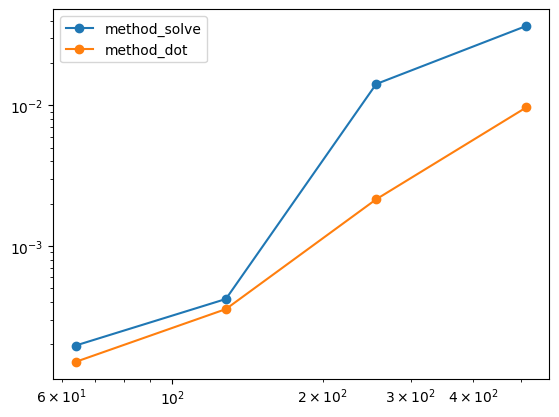

In [4]:
# Логарифмический график
n_vals = np.array([64, 128, 256, 512])
time_solve = np.array([
    196e-6,
    420e-6,
    14.2e-3,
    36.8e-3
])
time_dot = np.array([
    150e-6,
    356e-6,
    2.15e-3,
    9.7e-3
])

plt.loglog(n_vals, time_solve, 'o-', label='method_solve')
plt.loglog(n_vals, time_dot, 'o-', label='method_dot')
plt.legend()
plt.show()

In [5]:
# Оценка наклона
coef1 = np.polyfit(np.log(n_vals), np.log(time_solve), 1)
coef2 = np.polyfit(np.log(n_vals), np.log(time_dot), 1)
print('slope method_solve:', coef1[0])
print('slope method_dot:', coef2[0])

slope method_solve: 2.7737482696762887
slope method_dot: 2.063923853790834


In [6]:
# DCT-IV
def custom_dct4(signal):
    N = len(signal)
    times = (0.5 + np.arange(N)) / N
    freqs = (0.5 + np.arange(N)) / 2
    phase = np.outer(times, freqs)
    basis = np.cos(TWO_PI * phase)
    coeffs = basis.dot(signal) / 2
    return coeffs

# Сравнение с scipy
signal, freqs, times = generate_signal(512)
amps_manual = custom_dct4(signal)
amps_scipy = dct(signal, type=4) / 2

In [7]:
# Бенчмарк DCT
sizes = [64, 128, 256, 512, 1024, 2048]
for n in sizes:
    signal, freqs, times = generate_signal(n)
    print('N =', n)
    %timeit custom_dct4(signal)
    %timeit dct(signal, type=4)

N = 64
70.5 µs ± 9.49 µs per loop (mean ± std. dev. of 7 runs, 10000 loops each)
5.1 µs ± 2.01 µs per loop (mean ± std. dev. of 7 runs, 100000 loops each)
N = 128
228 µs ± 4.58 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)
4.05 µs ± 66.6 ns per loop (mean ± std. dev. of 7 runs, 100000 loops each)
N = 256
971 µs ± 165 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)
4.72 µs ± 69.9 ns per loop (mean ± std. dev. of 7 runs, 100000 loops each)
N = 512
5.29 ms ± 981 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)
5.98 µs ± 893 ns per loop (mean ± std. dev. of 7 runs, 100000 loops each)
N = 1024
23.3 ms ± 564 µs per loop (mean ± std. dev. of 7 runs, 10 loops each)
8.67 µs ± 1.42 µs per loop (mean ± std. dev. of 7 runs, 100000 loops each)
N = 2048
97.2 ms ± 12.5 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
13.4 µs ± 2.05 µs per loop (mean ± std. dev. of 7 runs, 100000 loops each)


На логарифмическом графике видно, что время работы method_solve растёт быстрее, чем у method_dot. Это объясняется тем, что method_solve использует np.linalg.solve со сложностью порядка N^3, а method_dot — умножение матрицы на вектор со сложностью около N^2. Поэтому method_dot работает эффективнее, особенно на больших данных.
При сравнении ручной реализации DCT-IV и scipy.fftpack.dct видно, что ручной вариант значительно медленнее из-за построения матрицы косинусов и матричного умножения. Встроенная функция SciPy работает быстрее за счёт оптимизированных алгоритмов, поэтому её предпочтительнее использовать на практике.

# Упражнение 6.2

In [11]:
wave = read_wave('100475__iluppai__saxophone-weep.wav')
wave.make_audio()

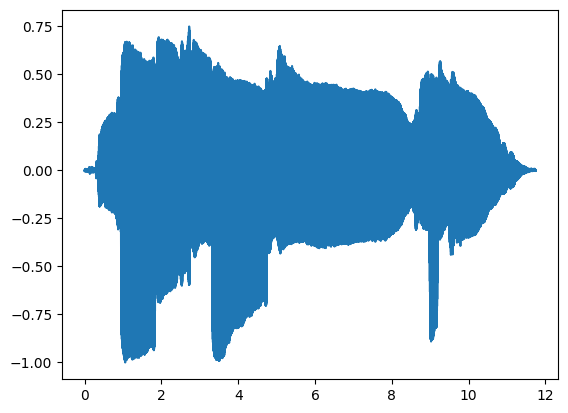

In [12]:
wave.plot()

In [13]:
def build_dct_spectrogram(wav, frame_size):
    win = np.hamming(frame_size)
    hop = frame_size // 2
    spec_dict = {}
    pos = 0
    while pos + frame_size < len(wav.ys):
        frame = wav.slice(pos, pos + frame_size)
        frame.window(win)
        center_time = (frame.start + frame.end) / 2
        spec_dict[center_time] = frame.make_dct()
        pos += hop
    return Spectrogram(spec_dict, frame_size)

In [14]:
def shrink_dct(dct_obj, threshold=1):
    removed = 0
    for idx, value in enumerate(dct_obj.amps):
        if abs(value) < threshold:
            dct_obj.hs[idx] = 0
            removed += 1
    return removed, len(dct_obj.amps)

In [15]:
# Сжатие всей спектрограммы
def shrink_spectrogram(spec, threshold=1):
    total_removed = 0
    total_coeffs = 0
    for spectrum in spec.spec_map.values():
        removed, n = shrink_dct(spectrum, threshold)
        total_removed += removed
        total_coeffs += n
    percent = 100 * total_removed / total_coeffs
    print('Удалено коэффициентов:', total_removed)
    print('Всего коэффициентов:', total_coeffs)
    print('Удалено, %:', percent)

In [16]:
# Применение
frame_size = 1024
dct_spec = build_dct_spectrogram(wave, frame_size)
shrink_spectrogram(dct_spec, threshold=1)

Удалено коэффициентов: 967837
Всего коэффициентов: 1034240
Удалено, %: 93.57953666460396


In [17]:
# Восстановление сигнала
new_wave = dct_spec.make_wave()
new_wave.normalize()
new_wave.make_audio()

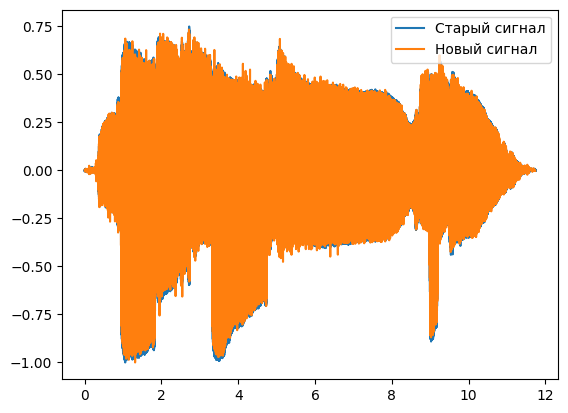

In [18]:
# Сравнение сигналов
wave.plot(label='Старый сигнал')
new_wave.plot(label='Новый сигнал')
plt.legend()
plt.show()

При сравнении исходного и восстановленного сигналов видно, что их форма в целом сохраняется. Это говорит о том, что после сжатия остались неизменными основные характеристики звука: длительность, огибающая и ключевые изменения амплитуды.
Однако при прослушивании восстановленного сигнала заметны искажения, проявляющиеся как дребезжание. Это означает, что ДКП-сжатие сохранило общую структуру сигнала, но привело к снижению качества звучания.

# Упражнение 6.3

При изменении фазовой структуры при сохранении амплитудного спектра звук в большинстве случаев остаётся узнаваемым и сохраняет свой характер. Это говорит о том, что слуховая система в большей степени чувствительна к распределению энергии по частотам, чем к точным фазовым соотношениям.

Однако при выборе других сегментов сигнала можно заметить, что в отдельных случаях изменение фазы приводит к незначительным изменениям тембра или локальных искажений, особенно для сложных или шумоподобных сигналов.

Таким образом, можно сделать вывод, что общие закономерности существуют: амплитудный спектр в большей степени определяет восприятие звука, тогда как фаза влияет на его тонкие детали и пространственно-временную структуру, но редко радикально меняет характер звука.